<a href="https://colab.research.google.com/github/miztarjoe24/Data-Science-Ecosystem/blob/main/MALL_CUSTOMERS_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
#Loading the dataset
df = pd.read_csv('https://docs.google.com/spreadsheets/d/1C621WcsIdWtH8rByqnHxXuJ-fqoxqi0pujcqEWgjdWE/export?format=csv')


In [ ]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                 

In [ ]:
#Exploring the data
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


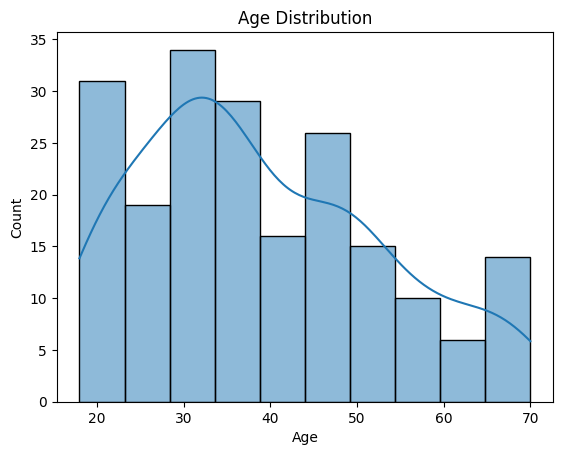

In [ ]:
# Plotting Histogram
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Age Distribution')
plt.show()

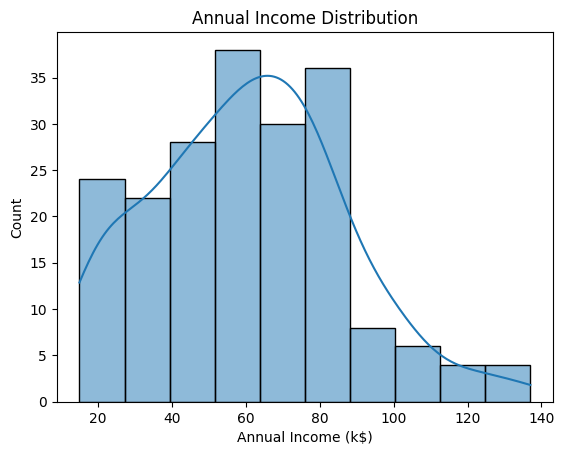

In [ ]:
sns.histplot(df['Annual Income (k$)'], bins=10, kde=True)
plt.title('Annual Income Distribution')
plt.show()


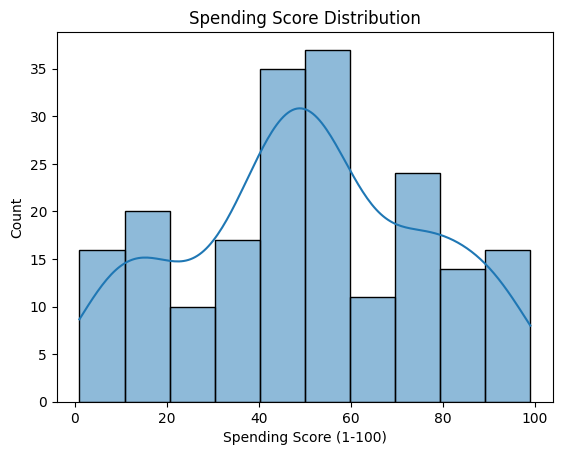

In [ ]:
sns.histplot(df['Spending Score (1-100)'], bins=10, kde=True)
plt.title('Spending Score Distribution')
plt.show()

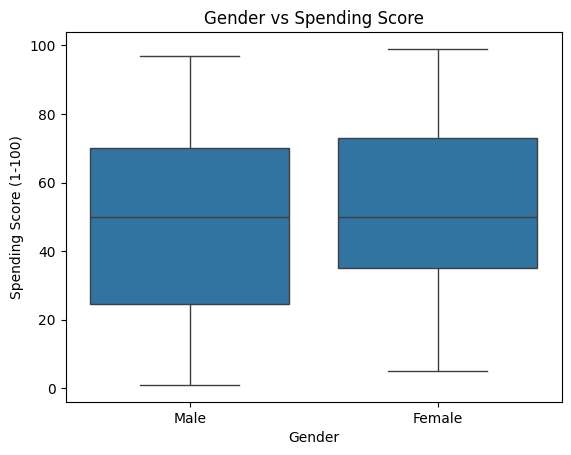

In [ ]:
# Optional: Gender vs Spending Score
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df)
plt.title('Gender vs Spending Score')
plt.show()


In [ ]:
#Selecting features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
# Step 5: Determine the optimal number of clusters using Elbow Method
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

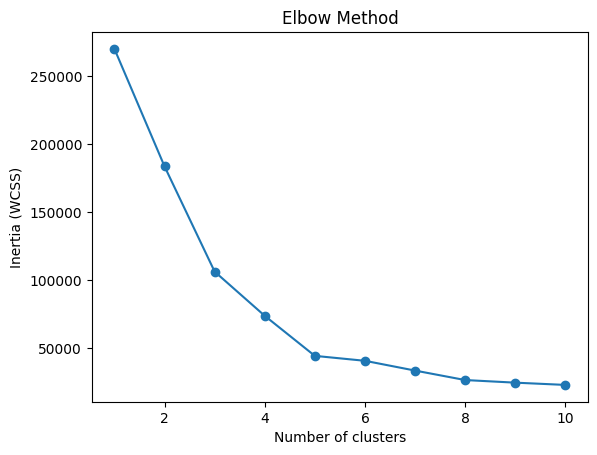

In [ ]:
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.show()

In [ ]:
# Silhouette Score for K=2 to 10
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'K={k}, Silhouette Score={score:.2f}')


K=2, Silhouette Score=0.40
K=3, Silhouette Score=0.47
K=4, Silhouette Score=0.49
K=5, Silhouette Score=0.55
K=6, Silhouette Score=0.51
K=7, Silhouette Score=0.50
K=8, Silhouette Score=0.50
K=9, Silhouette Score=0.46
K=10, Silhouette Score=0.44


In [ ]:
# Building K-Means Model
# Assuming optimal clusters K=5 based on Elbow/Silhouette
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

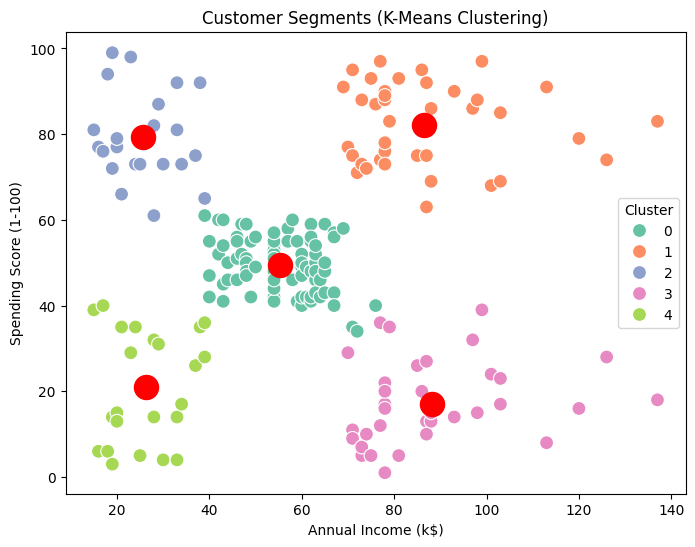

In [ ]:
# Visualizing the clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    data=df,
    s=100
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='red',
    label='Centroids'
)
plt.title('Customer Segments (K-Means Clustering)')
plt.show()

In [ ]:
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean()
print(cluster_summary)

# Short interpretations
for idx, row in cluster_summary.iterrows():
    income = row['Annual Income (k$)']
    spend = row['Spending Score (1-100)']
    desc = ''
    if income >= 70 and spend >= 70:
        desc = 'High income, high spenders'
    elif income >= 70 and spend < 70:
        desc = 'High income, low spenders'
    elif income < 70 and spend >= 70:
        desc = 'Low income, high spenders'
    elif income < 70 and spend < 70:
        desc = 'Low income, low spenders'
    else:
        desc = 'Medium segment'
    print(f'Cluster {idx}: {desc}')

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043
Cluster 0: Low income, low spenders
Cluster 1: High income, high spenders
Cluster 2: Low income, high spenders
Cluster 3: High income, low spenders
Cluster 4: Low income, low spenders


Customer Segment Insights

Target Customers – High income and high spending customers. These are the most valuable customers for the mall and should receive premium marketing offers.

Potential Big Spenders – Lower income but high spending behavior. Promotions and loyalty programs may increase their long-term value.

Careful High-Income Customers – High income but lower spending. Targeted marketing could encourage them to spend more.

Budget Customers – Low income and low spending customers who are less engaged.

Average Customers – Moderate income and spending, representing the general customer base.